## Heart Disease Prediction Analysis

In [2]:
########################
### Import libraries ###
########################

import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np

#### Data parsing, cleaning, and EDA

In [3]:
####################
### Read dataset ###
####################

file_path = 'data/heart_2020_cleaned.csv'
df = pd.read_csv(file_path)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [4]:
###############################
### Parse and clean dataset ###
###############################

# Replace '80 or older' with '80+' for better readability
df['AgeCategory'] = df['AgeCategory'].replace('80 or older', '80+')
# Convert binary string columns to numeric (1 for 'Yes', 0 for 'No')
binary_str_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke',
               'DiffWalking', 'Diabetic', 'PhysicalActivity', 'Asthma',
               'KidneyDisease', 'SkinCancer']
for col in binary_str_cols:
    df[col] = df[col].map(lambda x: 1 if x == "Yes" else 0)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,Female,55-59,White,1,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,Female,80+,White,0,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,Male,65-69,White,1,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,Female,75-79,White,0,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,Female,40-44,White,0,1,Very good,8.0,0,0,0


In [5]:
##########################
### Summary statistics ###
##########################

df.describe(include='all')

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.00000,319795.000000,319795.000000,319795,319795,319795,319795.000000,319795.000000,319795,319795.000000,319795.000000,319795.000000,319795.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,13,6,NaN,NaN,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,65-69,White,NaN,NaN,Very good,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167805,34151,245212,NaN,NaN,113858,NaN,NaN,NaN,NaN
mean,0.085595,28.325399,0.412477,0.068097,0.037740,3.37171,3.898366,0.138870,NaN,NaN,NaN,0.127588,0.775362,NaN,7.097075,0.134061,0.036833,0.093244
std,0.279766,6.356100,0.492281,0.251912,0.190567,7.95085,7.955235,0.345812,NaN,NaN,NaN,0.333631,0.417344,NaN,1.436007,0.340718,0.188352,0.290775
min,0.000000,12.020000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000
25%,0.000000,24.030000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,6.000000,0.000000,0.000000,0.000000
50%,0.000000,27.340000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,7.000000,0.000000,0.000000,0.000000
75%,0.000000,31.420000,1.000000,0.000000,0.000000,2.00000,3.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,8.000000,0.000000,0.000000,0.000000


#### Testing for association between age and heart disease

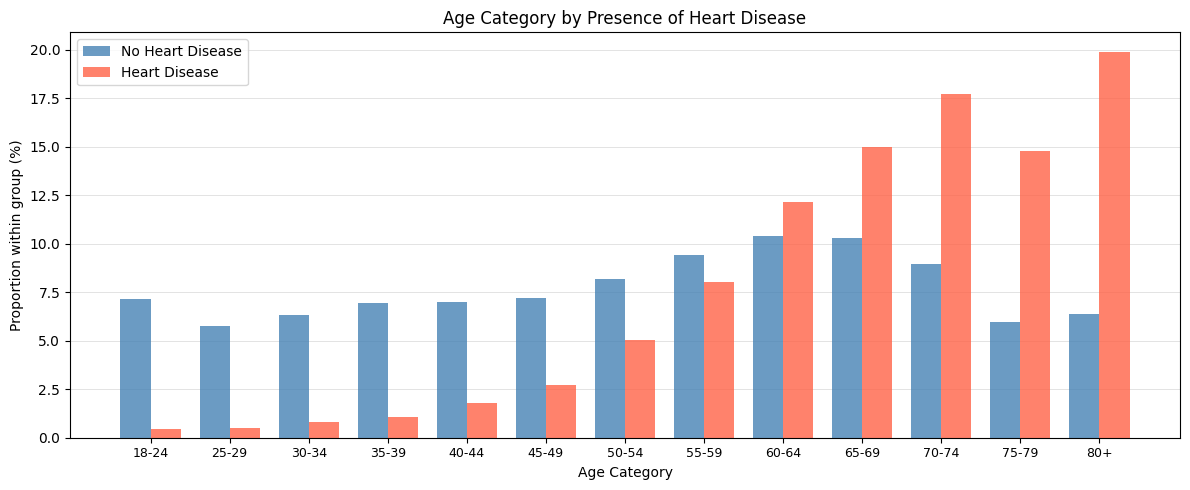

In [6]:
###################################################
### Visualize age distribution of heart disease ###
###################################################

age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']

true_counts  = df[df['HeartDisease'] == 1]['AgeCategory'].value_counts(normalize=True).reindex(age_order) * 100
false_counts  = df[df['HeartDisease'] == 0]['AgeCategory'].value_counts(normalize=True).reindex(age_order) * 100

x = np.arange(len(age_order))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, false_counts, width, label='No Heart Disease', color='steelblue', alpha=0.8)
ax.bar(x + width/2, true_counts, width, label='Heart Disease', color='tomato', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(age_order, fontsize=9)
ax.set_xlabel('Age Category')
ax.set_ylabel('Proportion within group (%)')
ax.set_title('Age Category by Presence of Heart Disease')
ax.legend()
ax.grid(axis='y', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [ ]:
# Chi-squared test for association between age category and heart disease
contingency = pd.crosstab(df['HeartDisease'], df['AgeCategory'])
res = stats.chi2_contingency(contingency)
print(f"Test Statistic: {res.statistic}")
print(f"p-value: {res.pvalue}")

Chi2: 19299.92039113256
p-value: 0.0


Since the p-value of the Chi-squared test is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant association between age category and heart disease. As seen in the grouped bar chart, the proportion of individuals with heart disease increases with age, suggesting that older age categories (specifically 60 and above) are more likely to have heart disease compared to younger age categories.

#### Investigating which races are more prone to heart disease

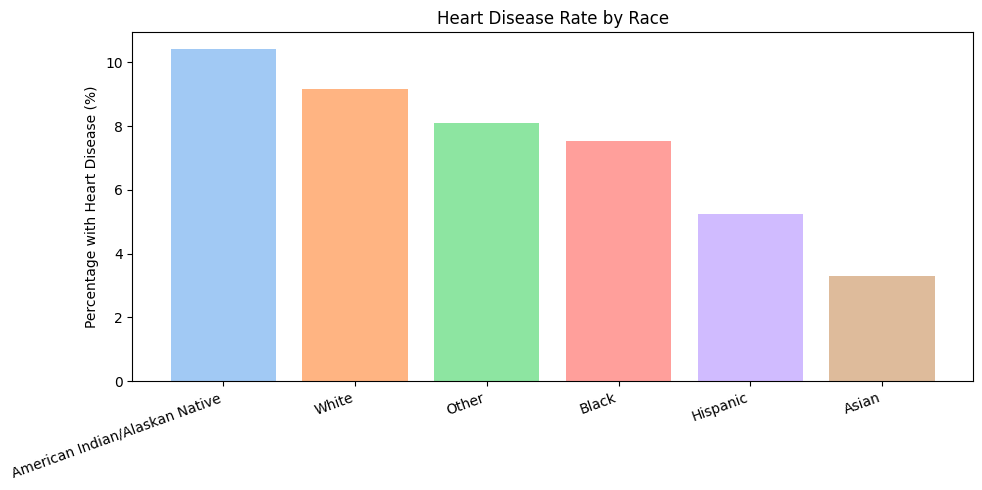

In [ ]:
################################################
### Visualize race of heart disease patients ###
################################################

# Proportion of each race that has heart disease
result = df.groupby('Race')['HeartDisease'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(result.index, result.values * 100, color=sns.color_palette('pastel', len(result)))
plt.ylabel('Percentage with Heart Disease (%)')
plt.title('Heart Disease Rate by Race')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Chi-squared test for association between race and heart disease
contingency = pd.crosstab(df['HeartDisease'], df['Race'])
res = stats.chi2_contingency(contingency)
print(f"Test Statistic: {res.statistic}")
print(f"p-value: {res.pvalue}")

Test Statistic: 844.3148859632537
p-value: 2.9886131565632592e-180


Since the p-value of the Chi-squared test is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant association between race and heart disease. As seen in the bar chart, American indians/Alaska Natives comprise the largest proportion suggesting heart disease is possibly more prevalent in this demographic.

### Checking for correlation between features

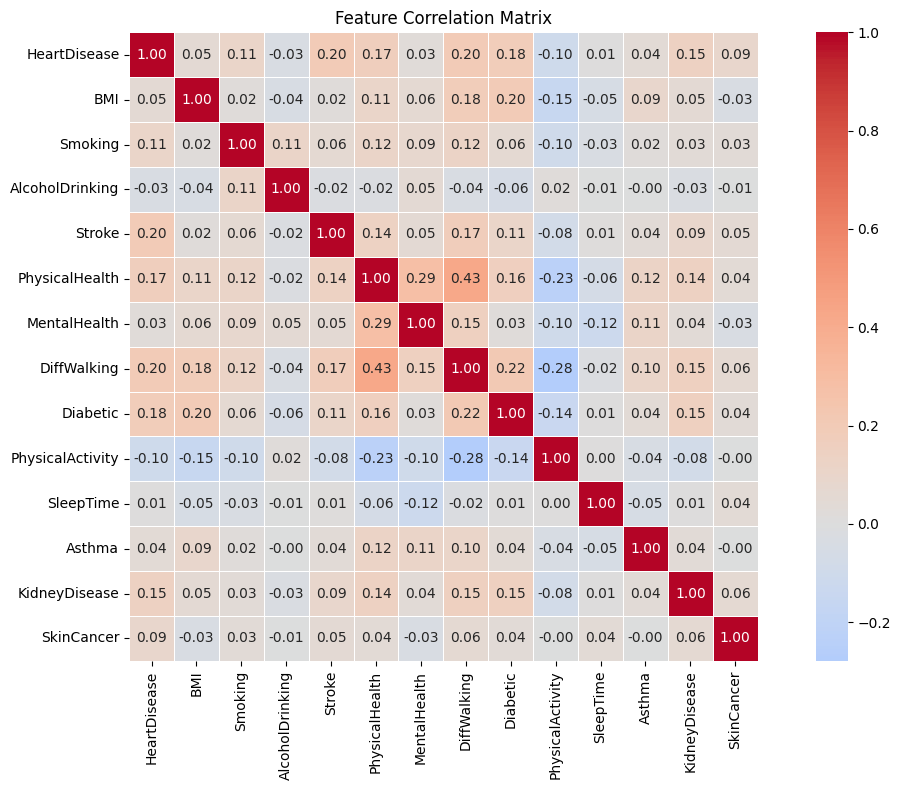

In [8]:
#################################################################################
### Use Pearson correlation for numeric features and visualize with a heatmap ###
#################################################################################

numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

It seems as though there are some slight correlations between features but most are relatively weak showing that most features are independent of one another. The most significant correlation was between PhysicalHealth and DiffWalking with a value of 0.43. This suggests that these features may be somewhat related which makes sense as they both relate to physical well-being. However, there are no extremely high correlations that would indicate any conflicting issues. This suggests that these features provide unique information for predicting heart disease.